In [4]:
import pandas as pd

df = pd.read_excel("data/Online Retail.xlsx")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Rows and Columns: (541909, 8)

Column Names:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


# Country-wise Order Analysis

This graph shows the number of orders placed from different countries. It helps understand customer distribution and order frequency across regions.

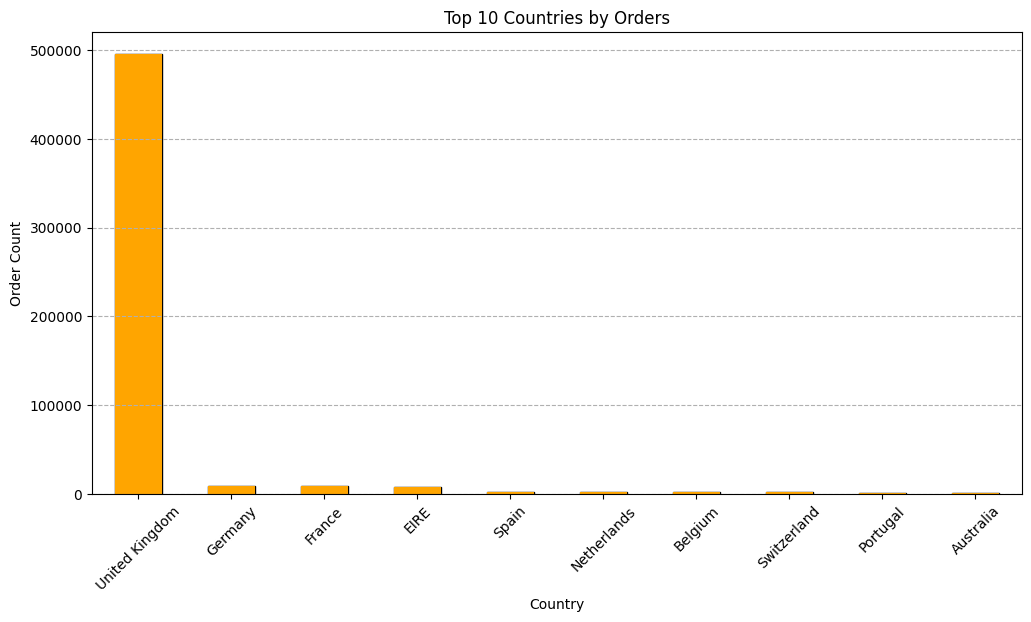

In [16]:
top_countries = df["Country"].value_counts().head(10)

plt.figure(figsize=(12,6))
top_countries.plot(
    kind="bar",
    color="royalblue",
    edgecolor="black"
)

plt.title("Top 10 Countries by Orders")
top_countries.plot(kind="bar", color="orange")
plt.xlabel("Country")
plt.ylabel("Order Count")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')

plt.show()

# Top Selling Products Analysis

This graph shows the 10 most frequently purchased products. It helps identify customer preferences and the products with the highest demand in the retail store.

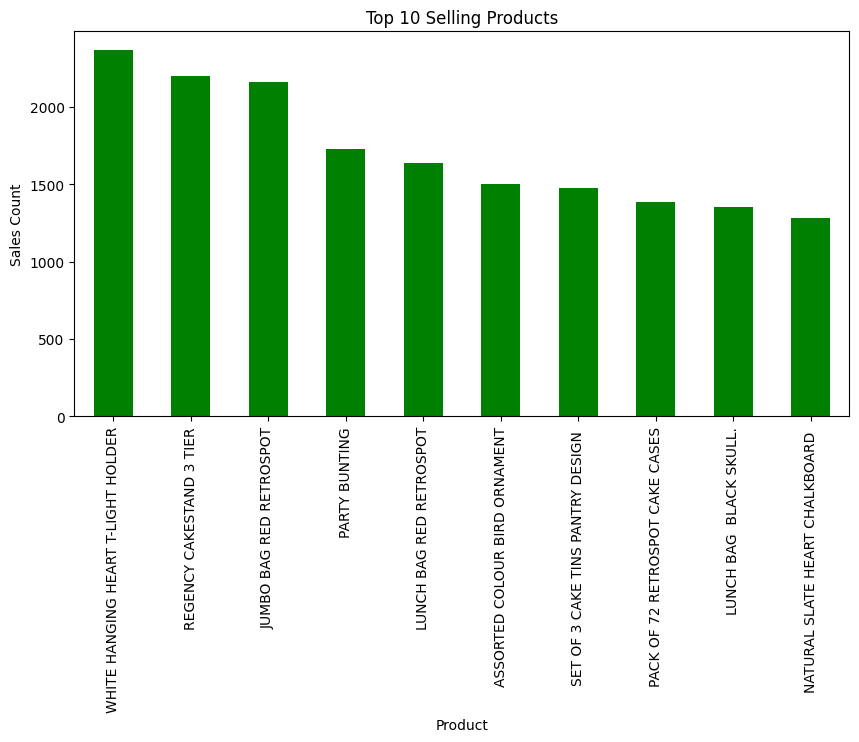

In [11]:
top_products = df["Description"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_products.plot(kind="bar", color="Green")
plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Sales Count")
plt.xticks(rotation=90)
plt.show()

# Country-wise Sales Quantity Analysis
This graph represents the total quantity of products sold across different countries. It helps identify the countries contributing the highest sales volume.


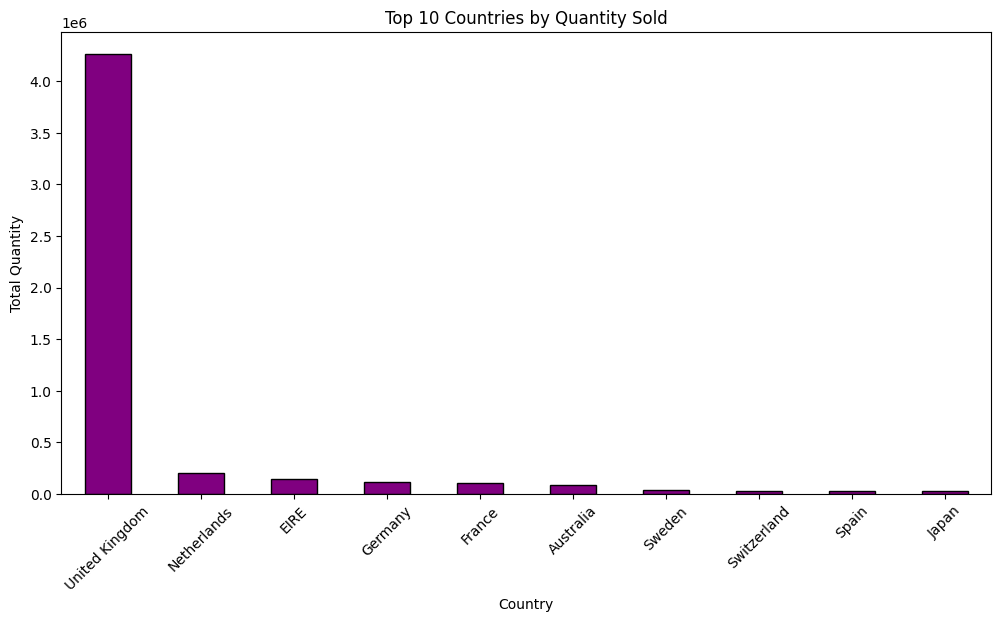

In [13]:
sales_by_country = df.groupby("Country")["Quantity"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sales_by_country.plot(
    kind="bar",
    color="purple",
    edgecolor="black"
)

plt.title("Top 10 Countries by Quantity Sold")
plt.xlabel("Country")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)

plt.show()

# Monthly Sales Trend Analysis

This graph illustrates the month-wise quantity of products sold. It helps analyze seasonal demand patterns and sales fluctuations throughout the year.

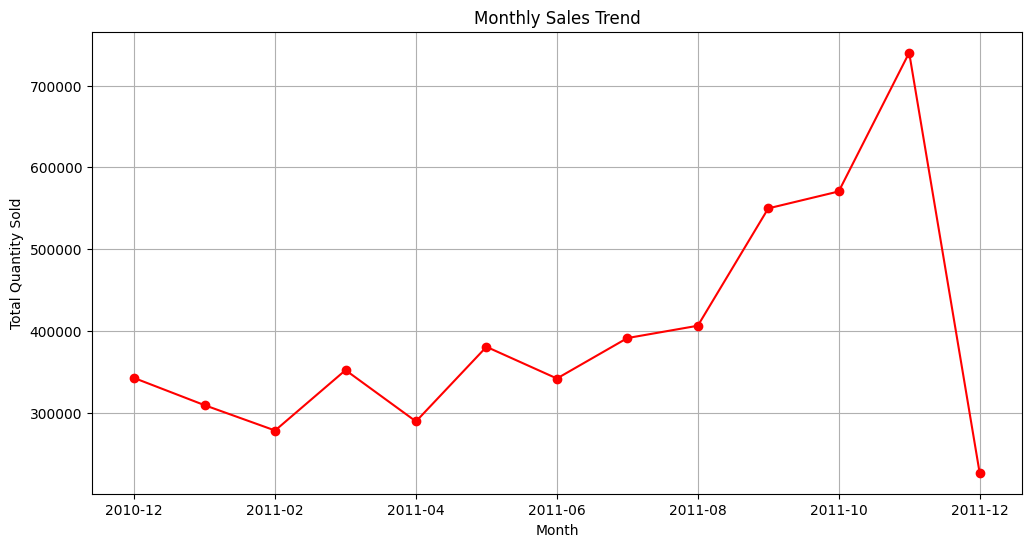

In [14]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

monthly_sales = df.groupby(
    df["InvoiceDate"].dt.to_period("M")
)["Quantity"].sum()

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12,6))

monthly_sales.plot(
    kind="line",
    color="red",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Quantity Sold")
plt.grid(True)

plt.show()

# Monthly Sales Growth Analysis

This graph highlights the trend of product sales over different months. It helps evaluate business performance and identify periods of high customer demand.

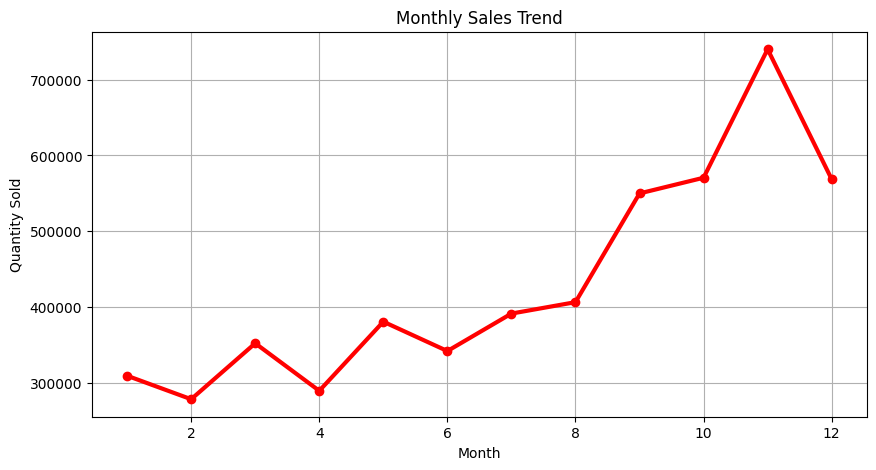

In [ ]:
monthly_sales = df.groupby(df["InvoiceDate"].dt.month)["Quantity"].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(
    kind="line",
    color="red",
    marker="o",
    linewidth=3
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Quantity Sold")
plt.grid(True)git add .
git commit -m "Updated EDA notebook"
git push
plt.show()

In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
df = df.dropna()

print("New Shape:", df.shape)

New Shape: (406829, 8)


In [6]:
df.duplicated().sum()

np.int64(5225)

In [7]:
df = df.drop_duplicates()

print("Final Shape:", df.shape)

Final Shape: (401604, 8)


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [10]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [15]:
import matplotlib.pyplot as plt

# Top Customers by Spending Analysis

This graph displays the top 10 customers based on their total spending. It helps identify high-value customers who contribute significantly to business revenue.

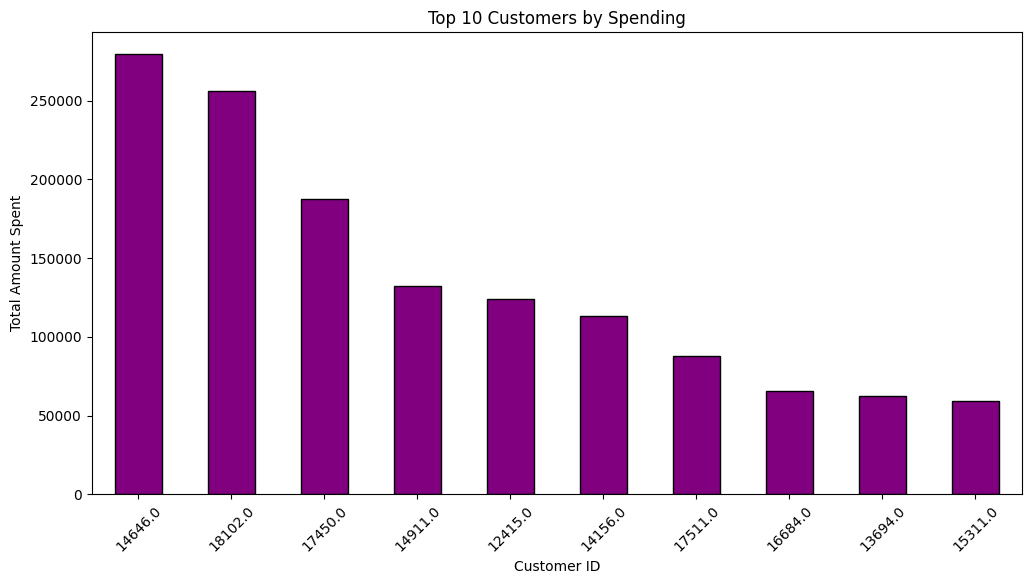

In [15]:
customer_sales = df.groupby("CustomerID")["TotalPrice"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
customer_sales.plot(
    kind="bar",
    color="purple",
    edgecolor="black"
)

plt.title("Top 10 Customers by Spending")
plt.xlabel("Customer ID")
plt.ylabel("Total Amount Spent")
plt.xticks(rotation=45)
plt.show()

# Top Products by Revenue Analysis

This graph shows the products generating the highest revenue. It helps identify the most profitable products in the retail business.

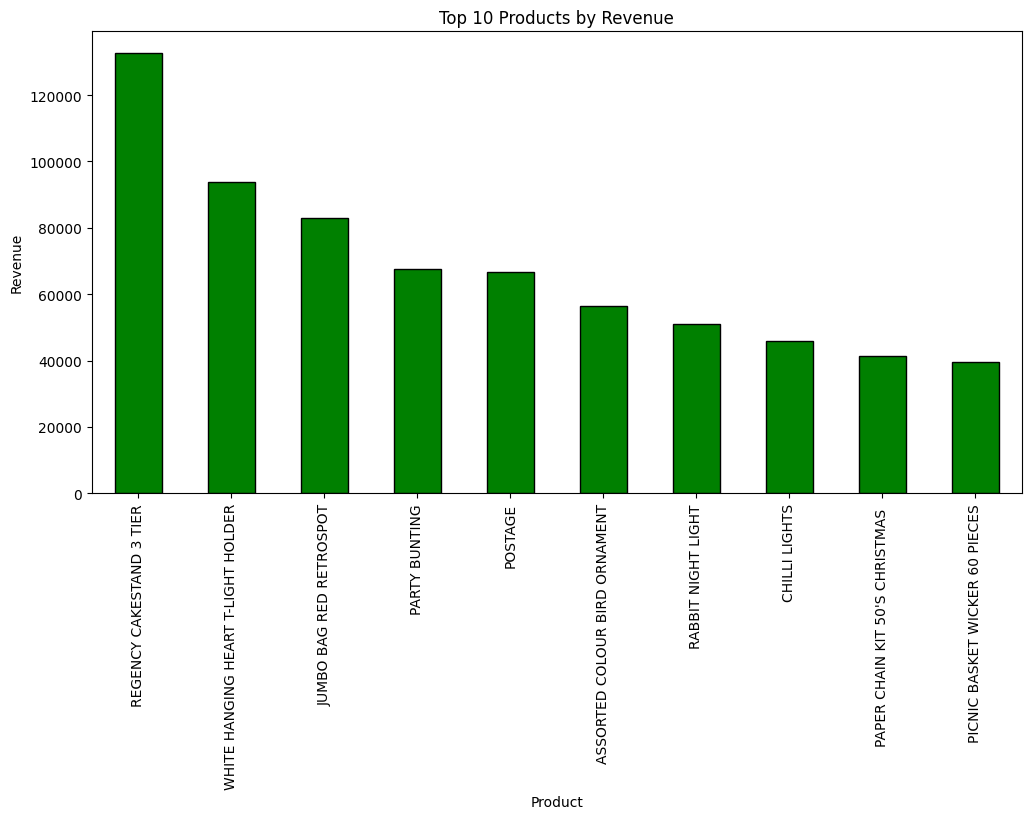

In [16]:
top_products_revenue = df.groupby("Description")["TotalPrice"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_products_revenue.plot(
    kind="bar",
    color="green",
    edgecolor="black"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=90)
plt.show()

# Country-wise Revenue Analysis

This graph represents the total revenue generated from different countries. It helps determine the most profitable geographic markets.

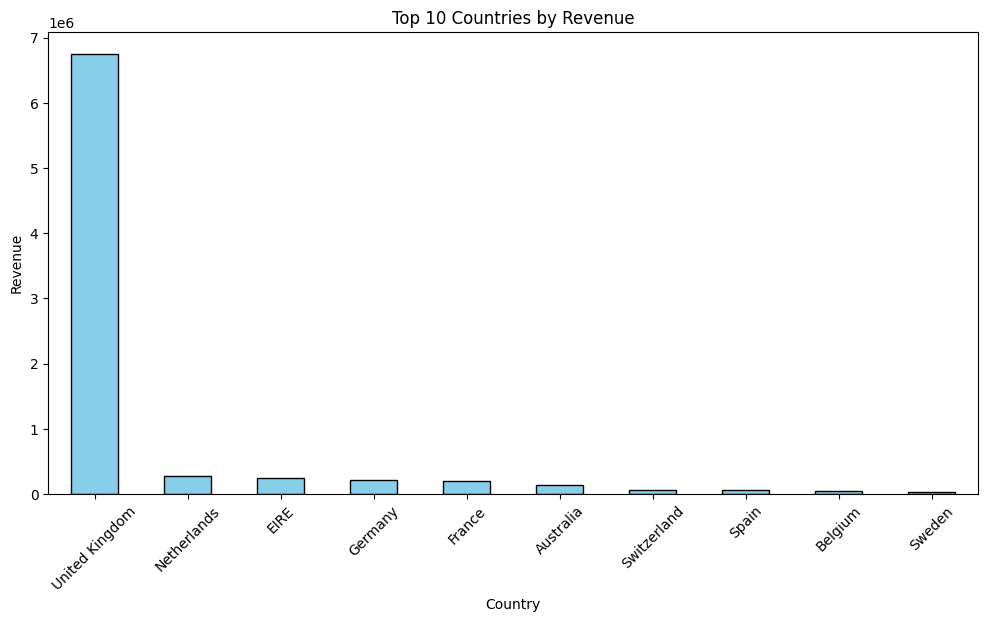

In [17]:
country_revenue = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
country_revenue.plot(
    kind="bar",
    color="skyblue",
    edgecolor="black"
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

# Monthly Revenue Trend Analysis

This graph illustrates the monthly revenue generated throughout the year. It helps identify revenue growth patterns and peak business periods.

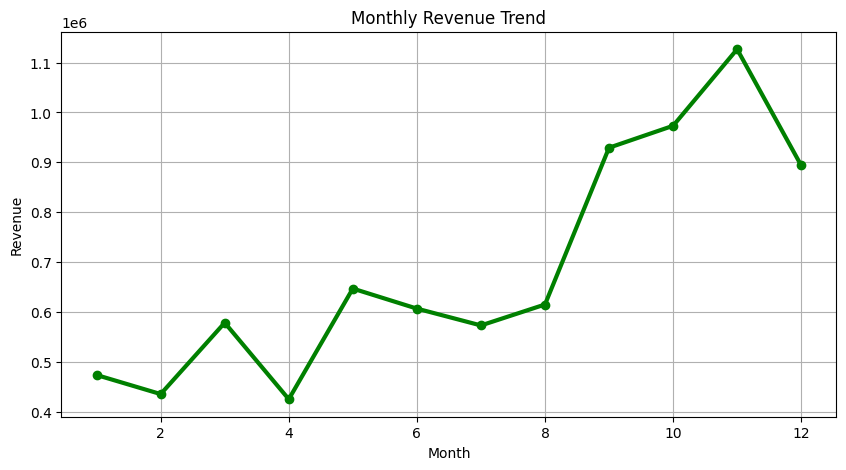

In [ ]:
monthly_revenue = df.groupby(df["InvoiceDate"].dt.month)["TotalPrice"].sum()

plt.figure(figsize=(10,5))

monthly_revenue.plot(
    kind="line",
    
    color="green",
    marker="o",
    linewidth=3
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)

plt.show()

In [6]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Demand Forecasting using Machine Learning

This section predicts future sales trends based on historical transaction data. The model helps retailers estimate future demand and make inventory decisions.

In [7]:
monthly_data = df.groupby(df['InvoiceDate'].dt.month)['TotalPrice'].sum().reset_index()

monthly_data.columns = ['Month', 'Revenue']

monthly_data

,Month,Revenue
0,1,560000.260
1,2,498062.650
2,3,683267.080
3,4,493207.121
4,5,723333.510
5,6,691123.120
6,7,681300.111
7,8,682680.510
8,9,1019687.622
9,10,1070704.670


In [8]:
X = monthly_data[['Month']]
y = monthly_data['Revenue']

print(X.head())
print(y.head())

   Month
0      1
1      2
2      3
3      4
4      5
0    560000.260
1    498062.650
2    683267.080
3    493207.121
4    723333.510
Name: Revenue, dtype: float64


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [11]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [12]:
y_pred = model.predict(X_test)

print(y_pred)

[1037997.31834497  975516.17622626  413185.89715782]


In [13]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 221920.59609031645
R2 Score: 0.4860553767016903


# Actual vs Predicted Revenue Analysis

This graph compares the actual revenue values with the revenue predicted by the machine learning model. It helps evaluate the forecasting performance of the model.

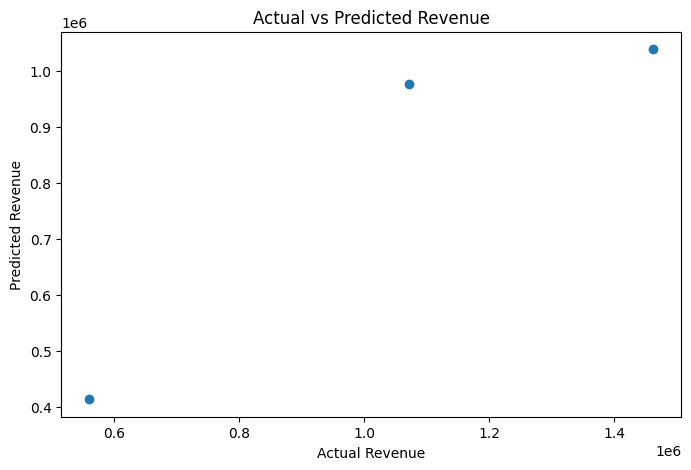

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue")

plt.show()

In [18]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 221920.59609031645
R2 Score: 0.4860553767016903


# Future Revenue Forecast

This section predicts the expected revenue for upcoming months using historical sales data and Linear Regression. The forecast helps businesses plan inventory and sales strategies.

In [19]:
future_months = pd.DataFrame({
    'Month':[13,14,15]
})

future_predictions = model.predict(future_months)

print("Future Revenue Predictions:")
print(future_predictions)

Future Revenue Predictions:
[1162959.6025824  1225440.74470112 1287921.88681983]


In [21]:
import os

os.makedirs("models", exist_ok=True)

In [22]:
import pickle

with open("models/forecast_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model Saved Successfully")

Model Saved Successfully
